# 11 - Descriptivos avanzados del subcorpus de salud

Equivalente al notebook `13_ciencia_admin_descriptivos.ipynb` de Karen.
Integra NER (NB06) y POS (NB08) para producir un analisis descriptivo
completo del subcorpus de salud, con comparacion por subcategoria.

**Entradas:**
- `salud_tweets_final.parquet`
- `corpus_cleaned.parquet`
- `general_ner.parquet`
- `verbos_salud_stanza.parquet` *(si NB08 ya corrio)*
- `adjetivos_salud_stanza.parquet` *(si NB08 ya corrio)*
- `sustantivos_salud_stanza.parquet` *(si NB08 ya corrio)*

**Salidas:** `descriptivos_avanzados_salud.xlsx`, figuras


In [7]:
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosComportamiento')

COLS_SUBCATS = [
    'Comp_Lavado_manos',
    'Comp_Desinfectante',
    'Comp_Mascarilla',
    'Comp_Etiqueta_tos_codo',
    'Comp_Etiqueta_tos_panuelo',
    'Comp_Distanciamiento',
    'Comp_Evitar_reuniones',
]

print('[CONFIG] OK')

SUBCATS_PRINCIPALES = [
    'Comp_Lavado_manos', 'Comp_Desinfectante', 'Comp_Mascarilla',
    'Comp_Distanciamiento', 'Comp_Evitar_reuniones',
]


[CONFIG] OK


In [8]:
import ast, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import spacy
from wordcloud import WordCloud
from collections import Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

corpus = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')
corpus['Fecha'] = pd.to_datetime(corpus['Fecha'], errors='coerce')

tweets_comp  = pd.read_parquet(DATA_PROCESSED / 'comportamiento_tweets_final.parquet')

df_comp  = tweets_comp.merge(
    corpus[['id_doc', 'Author_Normalized', 'Entidad', 'Fecha', 'Texto_limpio']],
    on='id_doc', how='left'
)
df_comp['Fecha']  = pd.to_datetime(df_comp['Fecha'], errors='coerce')

print(f'Corpus completo  : {len(corpus):,} tweets')
print(f'Subcorpus comp.  : {len(df_comp):,} tweets')
df_comp.head(2)


Corpus completo  : 151,424 tweets
Subcorpus comp.  : 2,804 tweets


,chunk_id,id_doc,texto_chunk,Comp_Desinfectante,Comp_Distanciamiento,Comp_Etiqueta_tos_codo,Comp_Etiqueta_tos_panuelo,Comp_Evitar_reuniones,Comp_Lavado_manos,Comp_Mascarilla,score_max,subcat_max,etiqueta_comportamiento,categoria_detectada,Author_Normalized,Entidad,Fecha,Texto_limpio
0,17_1,17,A esas horas el covid19 se queda en la casa mi...,0.037909,0.313174,0.314862,0.321228,0.509031,0.192823,0.118177,0.509031,Comp_Evitar_reuniones,1,Comp_Evitar_reuniones,@elima2219,Sin descripción,2020-06-03,A esas horas el covid19 se queda en la casa mi...
1,67_1,67,Los vendedores de balones de oxígeno y las pla...,0.253668,0.146621,0.448458,0.501524,0.200239,0.224089,0.342172,0.501524,Comp_Etiqueta_tos_panuelo,1,Comp_Etiqueta_tos_panuelo,@cmalcagmailcom1,Sin descripción,2020-06-03,Los vendedores de balones de oxígeno y las pla...


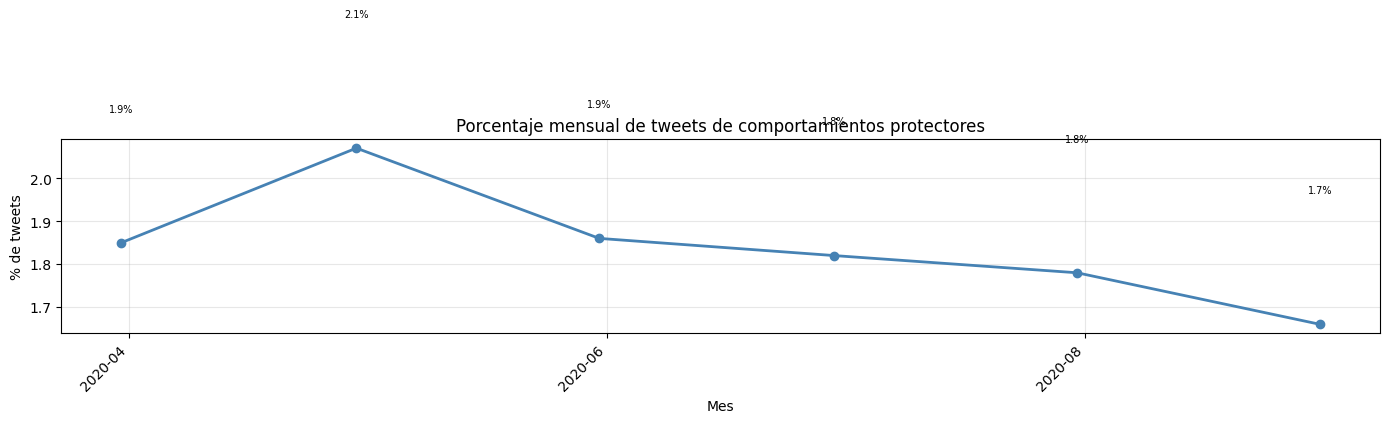

[GUARDADO] fig_porcentaje_mensual_comportamiento_avanzado.png


In [9]:
# Porcentaje mensual comportamientos / corpus total (replica de Karen)
total_mensual = corpus.groupby(pd.Grouper(key='Fecha', freq='ME')).size()
comp_mensual  = df_comp.groupby(pd.Grouper(key='Fecha', freq='ME'))['id_doc'].nunique()

mensual = pd.DataFrame({'total': total_mensual, 'comp': comp_mensual}).fillna(0)
mensual['porcentaje'] = (mensual['comp'] / mensual['total'] * 100).round(2)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(mensual.index, mensual['porcentaje'], marker='o', linestyle='-', color='steelblue', linewidth=2)
ax.set_title('Porcentaje mensual de tweets de comportamientos protectores')
ax.set_ylabel('% de tweets')
ax.set_xlabel('Mes')
ax.grid(alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')
for x, y in zip(mensual.index, mensual['porcentaje']):
    if not np.isnan(y) and y > 0:
        ax.text(x, y + 0.3, f'{y:.1f}%', ha='center', va='bottom', fontsize=7)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_porcentaje_mensual_comportamiento_avanzado.png', dpi=300)
plt.show()
print('[GUARDADO] fig_porcentaje_mensual_comportamiento_avanzado.png')


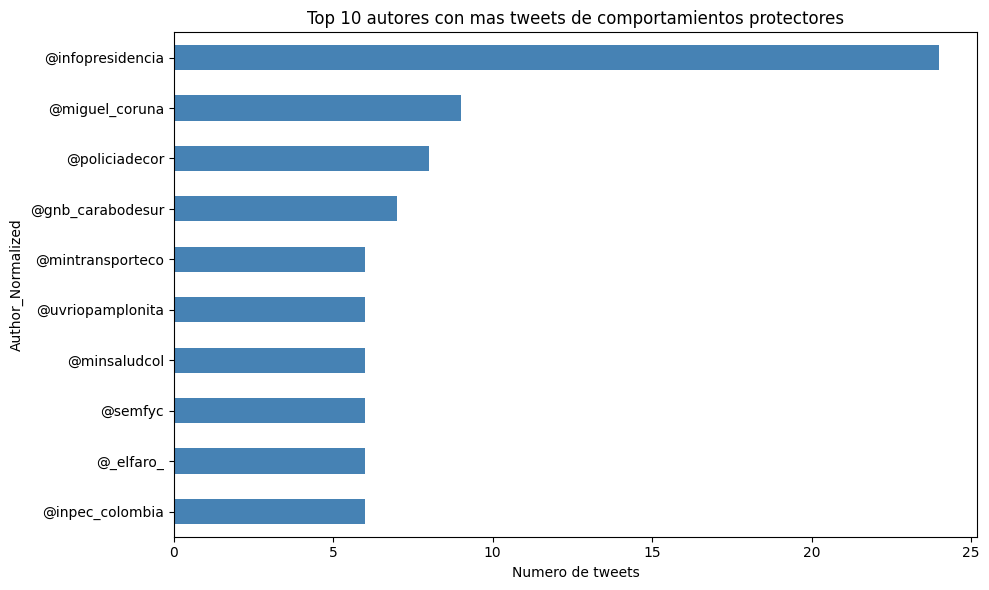

[GUARDADO] fig_top_autores_comportamiento_avanzado.png


In [10]:
# Top autores en subcorpus de comportamientos (replica de Karen)
top_autores = df_comp['Author_Normalized'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_autores.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 10 autores con mas tweets de comportamientos protectores')
ax.set_xlabel('Numero de tweets')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_autores_comportamiento_avanzado.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_autores_comportamiento_avanzado.png')


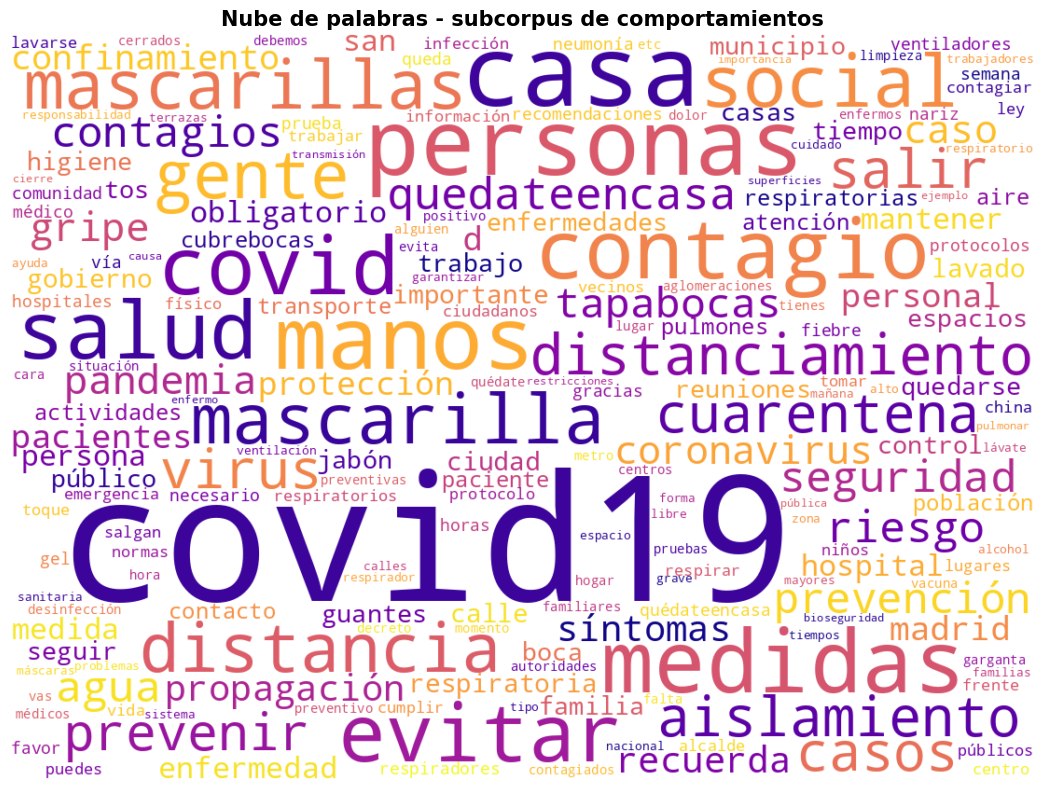

[GUARDADO] nube_subcorpus_comportamiento_avanzado.png


In [11]:
# Nube de palabras del subcorpus de comportamientos (replica de Karen)
nlp = spacy.load('es_core_news_sm')
STOP_WORDS = nlp.Defaults.stop_words
extra_sw = {'rt', 'http', 'https', 'co', 'amp', 'q', 'x', 'xq', 'via'}
STOP_WORDS = STOP_WORDS | extra_sw

texto_comp  = ' '.join(df_comp['Texto_limpio'].dropna().tolist()).lower()

wc = WordCloud(
    width=1100, height=800, background_color='white',
    max_words=200, stopwords=STOP_WORDS,
    prefer_horizontal=1.0, relative_scaling=0.5,
    collocations=False, random_state=42,
    min_font_size=10, colormap='plasma',
    normalize_plurals=False
).generate(texto_comp)

plt.figure(figsize=(12, 8))
plt.imshow(wc, interpolation='bilinear')
plt.title('Nube de palabras - subcorpus de comportamientos', fontsize=15, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'nube_subcorpus_comportamiento_avanzado.png', dpi=300)
plt.show()
print('[GUARDADO] nube_subcorpus_comportamiento_avanzado.png')


In [12]:
# Analisis NER: extraer y tabular entidades (replica de Karen)
def extract_entities(entities_array):
    entities_list = []
    if entities_array is None:
        return entities_list
    try:
        for item in entities_array:
            if hasattr(item, '__len__') and len(item) >= 2:
                entities_list.append((str(item[0]), str(item[1])))
    except Exception:
        pass
    return entities_list

ner_general = pd.read_parquet(DATA_PROCESSED / 'general_ner.parquet')
comportamiento_ids = set(df_comp['id_doc'])
ner_comp  = ner_general[ner_general['id_doc'].isin(comportamiento_ids)].copy()
print(f'Tweets en general_ner  : {len(ner_general):,}')
print(f'Tweets de comp. en NER  : {len(ner_comp):,}')


Tweets en general_ner  : 151,424
Tweets de comp. en NER  : 2,804


In [13]:
# Tabla de entidades comportamientos vs corpus completo (replica directa de Karen)
entidades_con_etiqueta = []

for _, row in tqdm(ner_general.iterrows(), total=len(ner_general), desc='NER global'):
    entidades = extract_entities(row['entidades'])
    es_comp   = 1 if row['id_doc'] in comportamiento_ids else 0
    for tipo, nombre in entidades:
        entidades_con_etiqueta.append({'tipo': tipo, 'nombre': nombre, 'etiqueta_comportamiento': es_comp})

df_ent = pd.DataFrame(entidades_con_etiqueta)

resultado_ner = (
    df_ent.groupby(['tipo', 'nombre'])
    .agg(frecuencia_total=('etiqueta_comportamiento', 'size'),
         frecuencia_comp=('etiqueta_comportamiento', lambda x: (x == 1).sum()))
    .reset_index()
)
resultado_ner['frecuencia_no_comp']  = resultado_ner['frecuencia_total'] - resultado_ner['frecuencia_comp']
resultado_ner['cociente_comp']  = (resultado_ner['frecuencia_comp'] / resultado_ner['frecuencia_total']).round(4)
resultado_ner.columns = ['Tipo','Entidad','Frecuencia_Total','Frecuencia_Comp','Frecuencia_No_Comp','Cociente_Comp']
resultado_ner = resultado_ner.sort_values('Frecuencia_Total', ascending=False).reset_index(drop=True)

print(f'Entidades unicas: {len(resultado_ner):,}')
print(resultado_ner.head(15).to_string(index=False))


NER global: 100%|██████████| 151424/151424 [00:02<00:00, 50973.11it/s]


Entidades unicas: 85,662
Tipo   Entidad  Frecuencia_Total  Frecuencia_Comp  Frecuencia_No_Comp  Cociente_Comp
MISC        Co             12742              143               12599         0.0112
MISC   Covid19              9697              255                9442         0.0263
 LOC  Colombia              8852               14                8838         0.0016
 LOC     China              7800               31                7769         0.0040
MISC   COVID19              6831              266                6565         0.0389
MISC     Covid              5589              107                5482         0.0191
 LOC    Madrid              5012               51                4961         0.0102
MISC        CO              4294              128                4166         0.0298
MISC     COVID              2479               92                2387         0.0371
 LOC    Bogotá              2414                6                2408         0.0025
 LOC      Cuba              2229        

In [14]:
# Analisis POS: frecuencias por subcategoria (replica de Karen)
# Karen compara freq_ciencia vs freq_total.
# Aqui la comparacion util es por subcategoria de comportamientos.
import ast

def asegurar_dict(x):
    if isinstance(x, dict):
        return {k: int(v) for k, v in x.items() if k is not None and v is not None}
    if isinstance(x, str):
        try:
            d = ast.literal_eval(x)
            return {k: int(v) for k, v in d.items() if k is not None and v is not None}
        except:
            return {}
    return {}


def construir_tabla_frecuencias_pos(df_pos, columna_dicts,
                                     df_comp_meta=None,
                                     subcats_principales=None):
    freq_total = Counter()
    freq_por_subcat = {s: Counter() for s in (subcats_principales or [])}

    # df_pos ya tiene subcat_max (guardada en NB08) -> usar directo
    if 'subcat_max' in df_pos.columns:
        df_work = df_pos.copy()
    elif df_comp_meta is not None:
        df_work = df_pos.merge(df_comp_meta[['id_doc', 'subcat_max']], on='id_doc', how='left')
    else:
        df_work = df_pos.copy()
        df_work['subcat_max'] = 'desconocida'

    for _, row in tqdm(df_work.iterrows(), total=len(df_work)):
        dic = asegurar_dict(row[columna_dicts])
        if not dic:
            continue
        freq_total.update(dic)
        subcat = row.get('subcat_max', '')
        if subcat in freq_por_subcat:
            freq_por_subcat[subcat].update(dic)

    data = []
    for palabra, f_total in freq_total.items():
        row_data = {'palabra': palabra, 'frecuencia_total': f_total}
        for s in (subcats_principales or []):
            label = s.replace('Comp_', '')
            f_s = freq_por_subcat[s].get(palabra, 0)
            row_data['freq_' + label] = f_s
            row_data['prop_' + label] = round(f_s / f_total, 4) if f_total > 0 else 0
        data.append(row_data)

    if not data:
        return pd.DataFrame()
    return pd.DataFrame(data).sort_values('frecuencia_total', ascending=False).reset_index(drop=True)


SUBCATS_PRINCIPALES = [
    'Comp_Lavado_manos',
    'Comp_Mascarilla',
    'Comp_Distanciamiento',
    'Comp_Evitar_reuniones',
    'Comp_Desinfectante',
]

try:
    df_verbos      = pd.read_parquet(DATA_PROCESSED / 'verbos_comportamiento_stanza.parquet')
    df_adjetivos   = pd.read_parquet(DATA_PROCESSED / 'adjetivos_comportamiento_stanza.parquet')
    df_sustantivos = pd.read_parquet(DATA_PROCESSED / 'sustantivos_comportamiento_stanza.parquet')

    comp_meta  = tweets_comp[['id_doc', 'subcat_max']].copy()

    print('subcat_max en df_verbos:', 'subcat_max' in df_verbos.columns)
    print('Construyendo tabla de verbos...')
    tabla_verbos = construir_tabla_frecuencias_pos(
        df_verbos, 'verbos_lemas_frecuencias', comp_meta, SUBCATS_PRINCIPALES)
    print('Construyendo tabla de adjetivos...')
    tabla_adjetivos = construir_tabla_frecuencias_pos(
        df_adjetivos, 'adjetivos_lemas_frecuencias', comp_meta, SUBCATS_PRINCIPALES)
    print('Construyendo tabla de sustantivos...')
    tabla_sustantivos = construir_tabla_frecuencias_pos(
        df_sustantivos, 'sustantivos_lemas_frecuencias', comp_meta, SUBCATS_PRINCIPALES)

    POS_OK = True
    print('POS OK')
    print('Columnas:', list(tabla_verbos.columns[:6]))
except FileNotFoundError:
    POS_OK = False
    print('[SKIP] Archivos POS no encontrados. Ejecuta primero el notebook 08.')


subcat_max en df_verbos: True
Construyendo tabla de verbos...


100%|██████████| 2804/2804 [00:00<00:00, 21212.89it/s]


Construyendo tabla de adjetivos...


100%|██████████| 2804/2804 [00:00<00:00, 21202.52it/s]


Construyendo tabla de sustantivos...


100%|██████████| 2804/2804 [00:00<00:00, 11526.80it/s]

POS OK
Columnas: ['palabra', 'frecuencia_total', 'freq_Lavado_manos', 'prop_Lavado_manos', 'freq_Mascarilla', 'prop_Mascarilla']


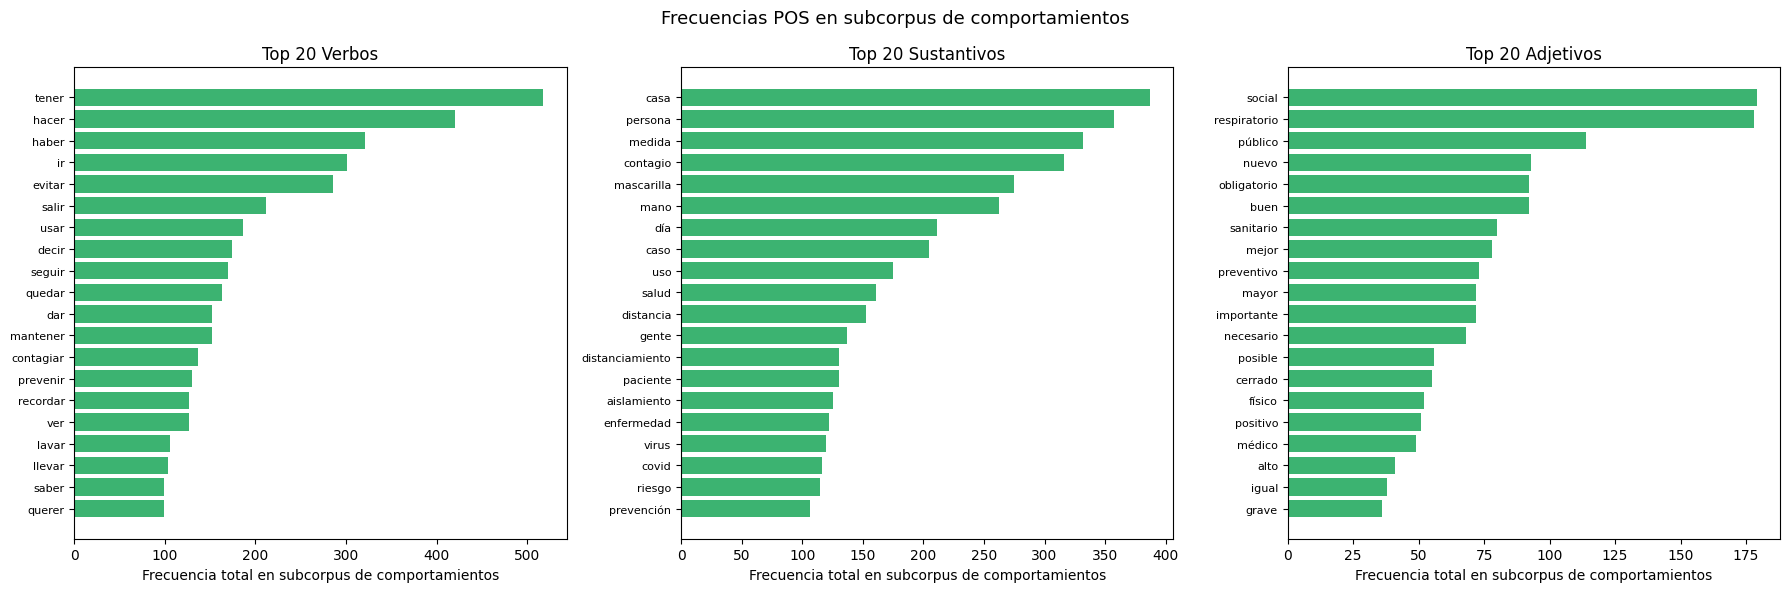

[GUARDADO] fig_pos_top_palabras_comp.png


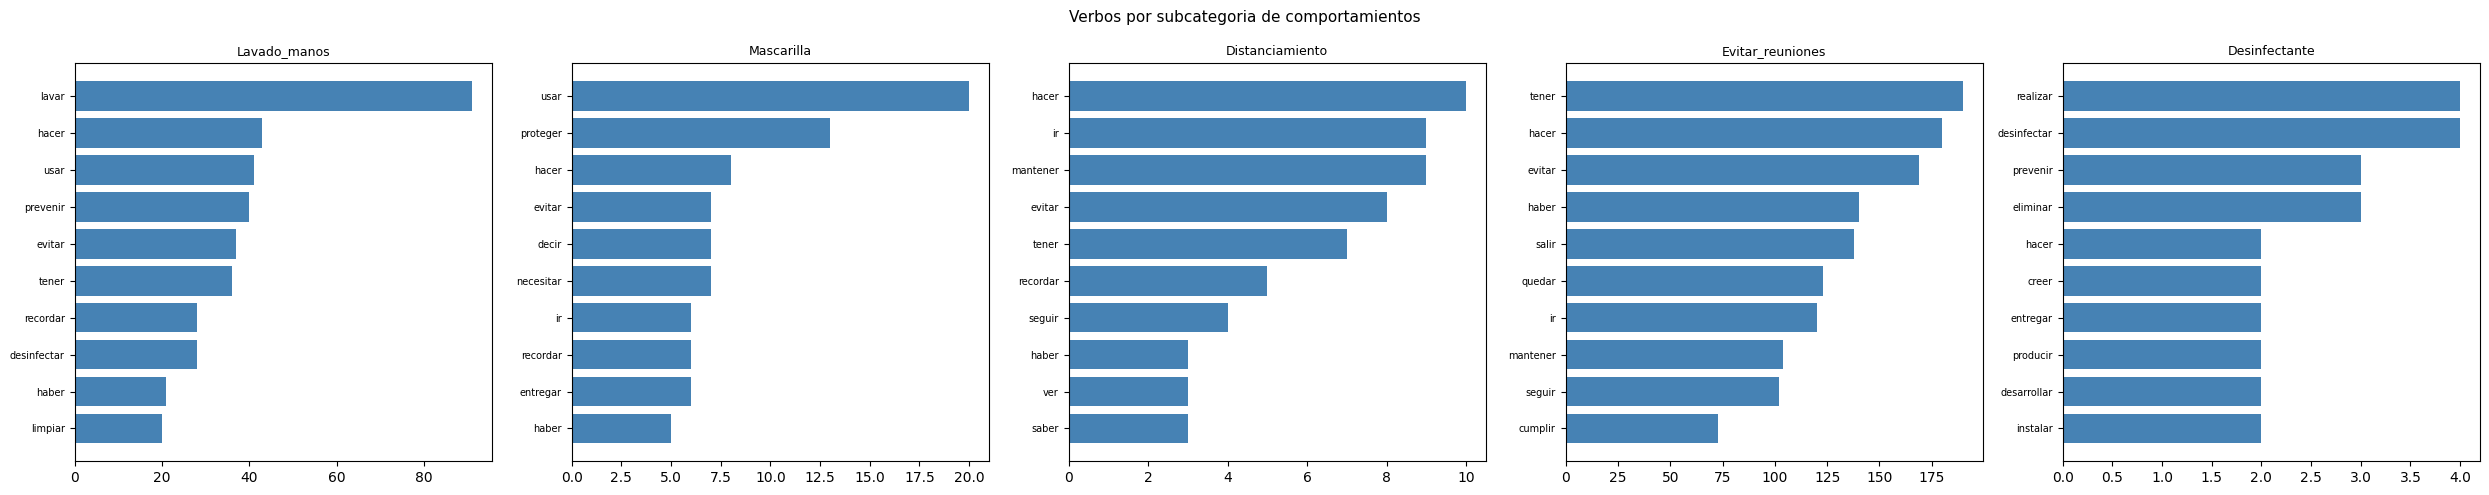

[GUARDADO] fig_pos_verbos_por_subcat.png


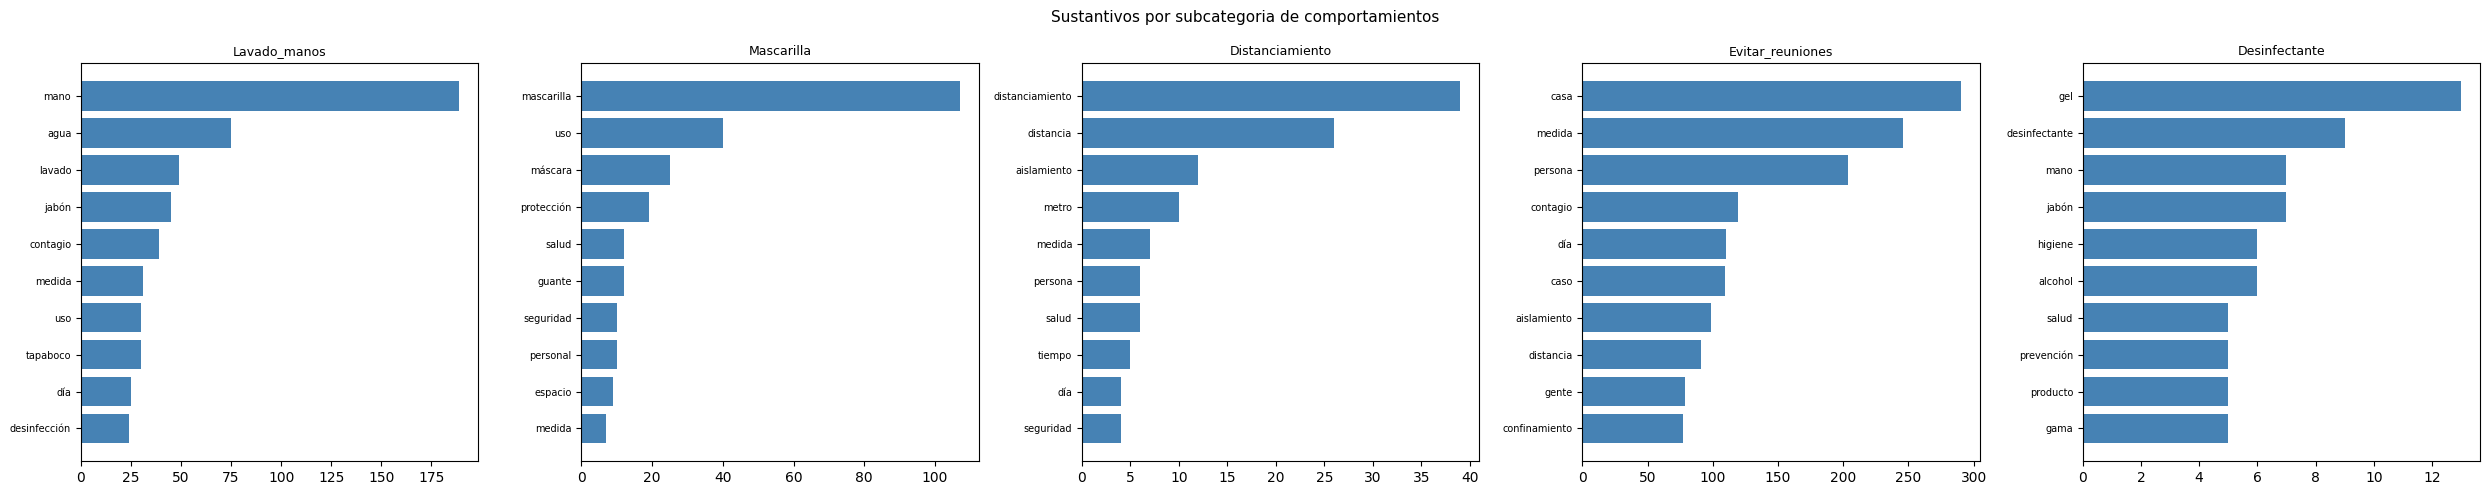

[GUARDADO] fig_pos_sustantivos_por_subcat.png


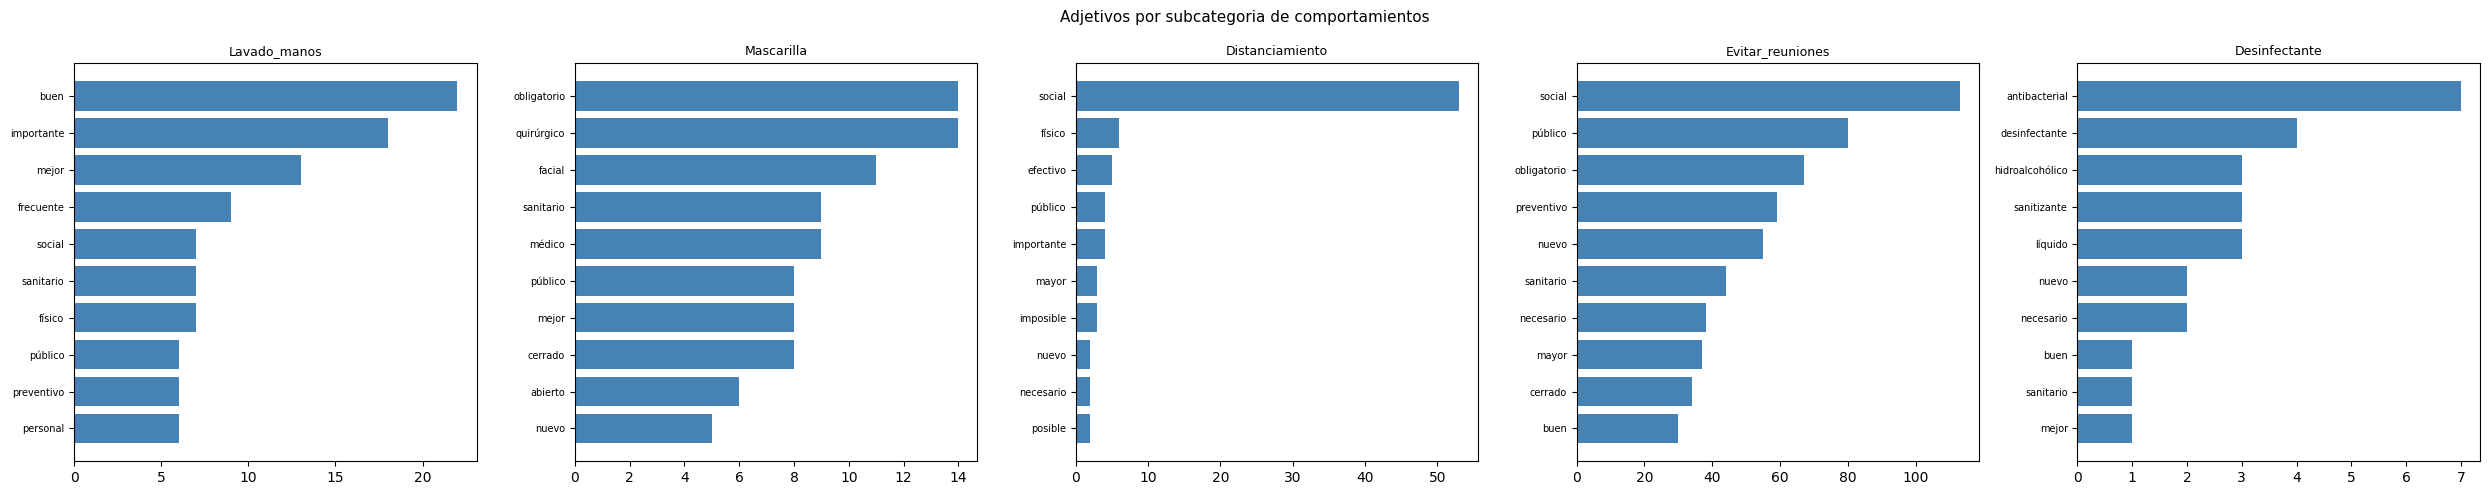

[GUARDADO] fig_pos_adjetivos_por_subcat.png


In [15]:
if POS_OK:
    # Grafico 1: top 20 por frecuencia total
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, tabla, titulo in zip(
        axes,
        [tabla_verbos, tabla_sustantivos, tabla_adjetivos],
        ['Top 20 Verbos', 'Top 20 Sustantivos', 'Top 20 Adjetivos']
    ):
        top20 = tabla.head(20).sort_values('frecuencia_total', ascending=True)
        ax.barh(top20['palabra'], top20['frecuencia_total'], color='mediumseagreen')
        ax.set_title(titulo)
        ax.set_xlabel('Frecuencia total en subcorpus de comportamientos')
        ax.tick_params(axis='y', labelsize=8)
    plt.suptitle('Frecuencias POS en subcorpus de comportamientos', fontsize=13)
    plt.tight_layout()
    plt.savefig(DATA_PROCESSED / 'fig_pos_top_palabras_comp.png', dpi=300)
    plt.show()
    print('[GUARDADO] fig_pos_top_palabras_comp.png')

    # Grafico 2: top 10 por subcategoria
    for tabla, tipo in [(tabla_verbos, 'Verbos'), (tabla_sustantivos, 'Sustantivos'), (tabla_adjetivos, 'Adjetivos')]:
        fig, axes = plt.subplots(1, len(SUBCATS_PRINCIPALES), figsize=(5*len(SUBCATS_PRINCIPALES), 5))
        for ax, subcat in zip(axes, SUBCATS_PRINCIPALES):
            col = 'freq_' + subcat.replace('Comp_', '')
            if col not in tabla.columns:
                ax.set_visible(False)
                continue
            top10 = tabla[tabla[col] > 0].nlargest(10, col)
            ax.barh(top10['palabra'], top10[col], color='steelblue')
            ax.set_title(subcat.replace('Comp_', ''), fontsize=9)
            ax.tick_params(axis='y', labelsize=7)
            ax.invert_yaxis()
        plt.suptitle(tipo + ' por subcategoria de comportamientos', fontsize=11)
        plt.tight_layout()
        ruta = DATA_PROCESSED / ('fig_pos_' + tipo.lower() + '_por_subcat.png')
        plt.savefig(ruta, dpi=300)
        plt.show()
        print('[GUARDADO]', ruta.name)
else:
    print('[SKIP] Ejecuta primero el notebook 08.')


In [16]:
# Guardar todo en Excel (replica de Karen)
ruta_excel = DATA_PROCESSED / 'descriptivos_avanzados_comportamiento.xlsx'

top_autores_df = top_autores.reset_index()
top_autores_df.columns = ['Autor', 'Tweets']

with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    mensual.reset_index().to_excel(writer, sheet_name='Porcentaje_mensual', index=False)
    top_autores_df.to_excel(writer,        sheet_name='Top_autores',        index=False)
    resultado_ner.to_excel(writer,         sheet_name='Entidades_NER_comp', index=False)
    if POS_OK:
        tabla_verbos.to_excel(writer,      sheet_name='POS_verbos',         index=False)
        tabla_adjetivos.to_excel(writer,   sheet_name='POS_adjetivos',      index=False)
        tabla_sustantivos.to_excel(writer, sheet_name='POS_sustantivos',    index=False)

print('[GUARDADO] descriptivos_avanzados_comportamiento.xlsx')
print()
print('Notebook 11 completado.')
print('Pipeline completo.')


[GUARDADO] descriptivos_avanzados_comportamiento.xlsx

Notebook 11 completado.
Pipeline completo.
